In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi']       = 120
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize']   = 13

orders    = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders = orders[orders['order_status'] == 'delivered']

merged = orders.merge(customers, on='customer_id')
merged['order_month'] = merged['order_purchase_timestamp'].dt.to_period('M')

print("Data loaded ✓")
print(f"Delivered orders : {len(orders):,}")
print(f"Unique customers : {merged['customer_unique_id'].nunique():,}")
print(f"Date range       : {merged['order_month'].min()} → {merged['order_month'].max()}")

Data loaded ✓
Delivered orders : 96,478
Unique customers : 93,358
Date range       : 2016-09 → 2018-08


In [2]:
# Cohort month = the month a customer placed their FIRST ever order
cohort_map = (
    merged
    .groupby('customer_unique_id')['order_month']
    .min()
    .reset_index()
    .rename(columns={'order_month': 'cohort_month'})
)

merged = merged.merge(cohort_map, on='customer_unique_id')

print("Cohort month assigned ✓")
print(f"\nSample — customer with their cohort:")
print(merged[['customer_unique_id','order_month','cohort_month']].head(8).to_string(index=False))

Cohort month assigned ✓

Sample — customer with their cohort:
              customer_unique_id order_month cohort_month
7c396fd4830fd04220f754e42b4e5bff     2017-10      2017-09
af07308b275d755c9edb36a90c618231     2018-07      2018-07
3a653a41f6f9fc3d2a113cf8398680e8     2018-08      2018-08
7c142cf63193a1473d2e66489a9ae977     2017-11      2017-11
72632f0f9dd73dfee390c9b22eb56dd6     2018-02      2018-02
80bb27c7c16e8f973207a5086ab329e2     2017-07      2017-07
932afa1e708222e5821dac9cd5db4cae     2017-05      2017-05
39382392765b6dc74812866ee5ee92a7     2017-01      2017-01


In [3]:
# Cohort index = how many months after their first purchase this order happened
# Index 0 = first purchase month, Index 1 = one month later, etc.

merged['cohort_index'] = (
    merged['order_month'].dt.start_time.dt.to_period('M').astype(int) -
    merged['cohort_month'].dt.start_time.dt.to_period('M').astype(int)
)

print("Cohort index calculated ✓")
print("\nIndex meaning:")
print("  0 = month customer first purchased")
print("  1 = one month after first purchase")
print("  2 = two months after first purchase  etc.")
print("\nSample:")
print(merged[['customer_unique_id','cohort_month',
              'order_month','cohort_index']].head(10).to_string(index=False))

Cohort index calculated ✓

Index meaning:
  0 = month customer first purchased
  1 = one month after first purchase
  2 = two months after first purchase  etc.

Sample:
              customer_unique_id cohort_month order_month  cohort_index
7c396fd4830fd04220f754e42b4e5bff      2017-09     2017-10             1
af07308b275d755c9edb36a90c618231      2018-07     2018-07             0
3a653a41f6f9fc3d2a113cf8398680e8      2018-08     2018-08             0
7c142cf63193a1473d2e66489a9ae977      2017-11     2017-11             0
72632f0f9dd73dfee390c9b22eb56dd6      2018-02     2018-02             0
80bb27c7c16e8f973207a5086ab329e2      2017-07     2017-07             0
932afa1e708222e5821dac9cd5db4cae      2017-05     2017-05             0
39382392765b6dc74812866ee5ee92a7      2017-01     2017-01             0
299905e3934e9e181bfb2e164dd4b4f8      2017-07     2017-07             0
f2a85dec752b8517b5e58a06ff3cd937      2017-05     2017-05             0


In [4]:
# Count unique customers per cohort per month index
cohort_data = (
    merged
    .groupby(['cohort_month', 'cohort_index'])['customer_unique_id']
    .nunique()
    .reset_index()
    .rename(columns={'customer_unique_id': 'customers'})
)

# Pivot: rows = cohort month, columns = cohort index
cohort_pivot = cohort_data.pivot_table(
    index   = 'cohort_month',
    columns = 'cohort_index',
    values  = 'customers'
)

# Filter to 2017 and 2018 cohorts only (clean data window)
cohort_pivot = cohort_pivot[
    cohort_pivot.index.astype(str).str.startswith(('2017','2018'))
]

print("Cohort pivot table built ✓")
print(f"Shape: {cohort_pivot.shape}  (cohorts × months)")
print(f"\nCohort sizes (column 0 = first month):")
print(cohort_pivot[0].to_string())

Cohort pivot table built ✓
Shape: (20, 20)  (cohorts × months)

Cohort sizes (column 0 = first month):
cohort_month
2017-01     717.0
2017-02    1628.0
2017-03    2503.0
2017-04    2256.0
2017-05    3451.0
2017-06    3037.0
2017-07    3752.0
2017-08    4057.0
2017-09    4004.0
2017-10    4328.0
2017-11    7060.0
2017-12    5338.0
2018-01    6842.0
2018-02    6288.0
2018-03    6774.0
2018-04    6582.0
2018-05    6506.0
2018-06    5878.0
2018-07    5949.0
2018-08    6144.0
Freq: M


In [5]:
# Cohort size = number of customers at index 0 (first month)
cohort_size = cohort_pivot[0]

# Retention rate = customers in month N / customers in month 0
retention_df = cohort_pivot.divide(cohort_size, axis=0).round(4)

print("Retention rate table built ✓")
print(f"\nRetention rates (first 6 months):")
print((retention_df.iloc[:, :7] * 100).round(2).to_string())

Retention rate table built ✓

Retention rates (first 6 months):
cohort_index      0     1     2     3     4     5     6
cohort_month                                           
2017-01       100.0  0.28  0.28  0.14  0.42  0.14  0.42
2017-02       100.0  0.18  0.31  0.12  0.43  0.12  0.25
2017-03       100.0  0.44  0.36  0.40  0.36  0.16  0.16
2017-04       100.0  0.62  0.22  0.18  0.27  0.27  0.35
2017-05       100.0  0.46  0.46  0.29  0.29  0.32  0.41
2017-06       100.0  0.49  0.40  0.43  0.30  0.40  0.36
2017-07       100.0  0.53  0.35  0.24  0.29  0.21  0.32
2017-08       100.0  0.69  0.35  0.27  0.35  0.52  0.30
2017-09       100.0  0.70  0.55  0.27  0.45  0.22  0.22
2017-10       100.0  0.72  0.25  0.09  0.23  0.21  0.21
2017-11       100.0  0.57  0.37  0.17  0.17  0.18  0.11
2017-12       100.0  0.21  0.28  0.34  0.26  0.21  0.17
2018-01       100.0  0.34  0.37  0.29  0.29  0.16  0.18
2018-02       100.0  0.35  0.40  0.30  0.25  0.22  0.21
2018-03       100.0  0.40  0.30  0.30  0

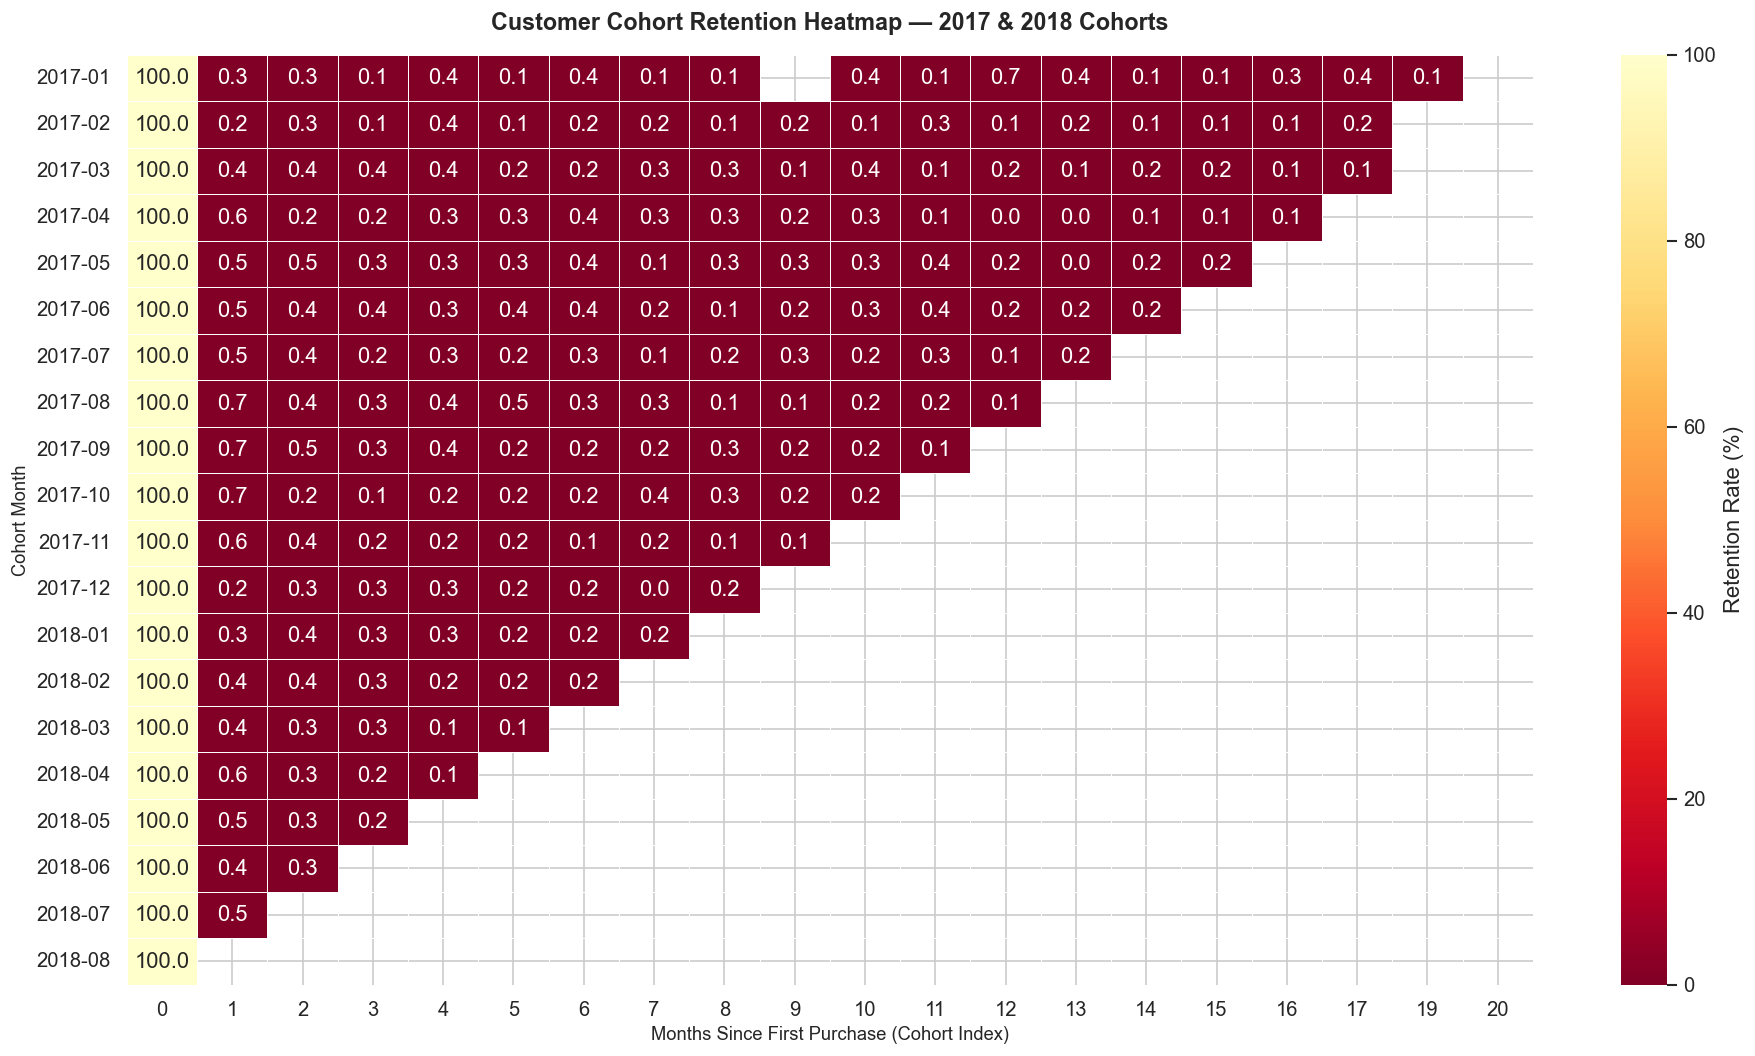

Key insight: Column 0 is always 100% — that is the baseline (first purchase month)
Every column after shows what % of those original customers returned
Avg retention at month 1 : 0.48%
Avg retention at month 3 : 0.25%


In [6]:
fig, ax = plt.subplots(figsize=(16, 9))

# Multiply by 100 for percentage display
retention_pct = retention_df * 100

sns.heatmap(
    retention_pct,
    annot      = True,
    fmt        = '.1f',
    cmap       = 'YlOrRd_r',
    linewidths = 0.5,
    linecolor  = 'white',
    ax         = ax,
    vmin       = 0,
    vmax       = 100,
    cbar_kws   = {'label': 'Retention Rate (%)'}
)

ax.set_title('Customer Cohort Retention Heatmap — 2017 & 2018 Cohorts',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Purchase (Cohort Index)', fontsize=11)
ax.set_ylabel('Cohort Month', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("Key insight: Column 0 is always 100% — that is the baseline (first purchase month)")
print("Every column after shows what % of those original customers returned")
print(f"Avg retention at month 1 : {retention_pct[1].mean():.2f}%")
print(f"Avg retention at month 3 : {retention_pct[3].mean():.2f}%")

In [7]:
cohorts_2017 = retention_df[retention_df.index.astype(str).str.startswith('2017')]
cohorts_2018 = retention_df[retention_df.index.astype(str).str.startswith('2018')]

print(f"2017 cohorts : {len(cohorts_2017)} monthly cohorts")
print(f"2018 cohorts : {len(cohorts_2018)} monthly cohorts")

print(f"\n=== 2017 Average Retention by Month Index ===")
avg_2017 = (cohorts_2017.mean() * 100).round(2)
for idx, val in avg_2017.dropna().items():
    print(f"  Month {int(idx):>2} : {val:.2f}%")

print(f"\n=== 2018 Average Retention by Month Index ===")
avg_2018 = (cohorts_2018.mean() * 100).round(2)
for idx, val in avg_2018.dropna().items():
    print(f"  Month {int(idx):>2} : {val:.2f}%")

2017 cohorts : 12 monthly cohorts
2018 cohorts : 8 monthly cohorts

=== 2017 Average Retention by Month Index ===
  Month  0 : 100.00%
  Month  1 : 0.49%
  Month  2 : 0.35%
  Month  3 : 0.25%
  Month  4 : 0.32%
  Month  5 : 0.25%
  Month  6 : 0.27%
  Month  7 : 0.21%
  Month  8 : 0.21%
  Month  9 : 0.17%
  Month 10 : 0.26%
  Month 11 : 0.21%
  Month 12 : 0.21%
  Month 13 : 0.17%
  Month 14 : 0.15%
  Month 15 : 0.15%
  Month 16 : 0.14%
  Month 17 : 0.24%
  Month 19 : 0.14%

=== 2018 Average Retention by Month Index ===
  Month  0 : 100.00%
  Month  1 : 0.45%
  Month  2 : 0.32%
  Month  3 : 0.26%
  Month  4 : 0.20%
  Month  5 : 0.17%
  Month  6 : 0.19%
  Month  7 : 0.23%


In [8]:
size_2017 = cohort_pivot[cohort_pivot.index.astype(str).str.startswith('2017')][0]
size_2018 = cohort_pivot[cohort_pivot.index.astype(str).str.startswith('2018')][0]

print("=== Cohort Sizes ===")
print(f"\n2017 cohorts:")
print(size_2017.to_string())
print(f"\n  Total new customers in 2017 : {size_2017.sum():,.0f}")
print(f"  Avg monthly cohort size     : {size_2017.mean():,.0f}")

print(f"\n2018 cohorts:")
print(size_2018.to_string())
print(f"\n  Total new customers in 2018 : {size_2018.sum():,.0f}")
print(f"  Avg monthly cohort size     : {size_2018.mean():,.0f}")

growth = ((size_2018.mean() - size_2017.mean()) / size_2017.mean() * 100).round(1)
print(f"\n  Cohort size growth 2017→2018: +{growth}%")

=== Cohort Sizes ===

2017 cohorts:
cohort_month
2017-01     717.0
2017-02    1628.0
2017-03    2503.0
2017-04    2256.0
2017-05    3451.0
2017-06    3037.0
2017-07    3752.0
2017-08    4057.0
2017-09    4004.0
2017-10    4328.0
2017-11    7060.0
2017-12    5338.0
Freq: M

  Total new customers in 2017 : 42,131
  Avg monthly cohort size     : 3,511

2018 cohorts:
cohort_month
2018-01    6842.0
2018-02    6288.0
2018-03    6774.0
2018-04    6582.0
2018-05    6506.0
2018-06    5878.0
2018-07    5949.0
2018-08    6144.0
Freq: M

  Total new customers in 2018 : 50,963
  Avg monthly cohort size     : 6,370

  Cohort size growth 2017→2018: +81.4%


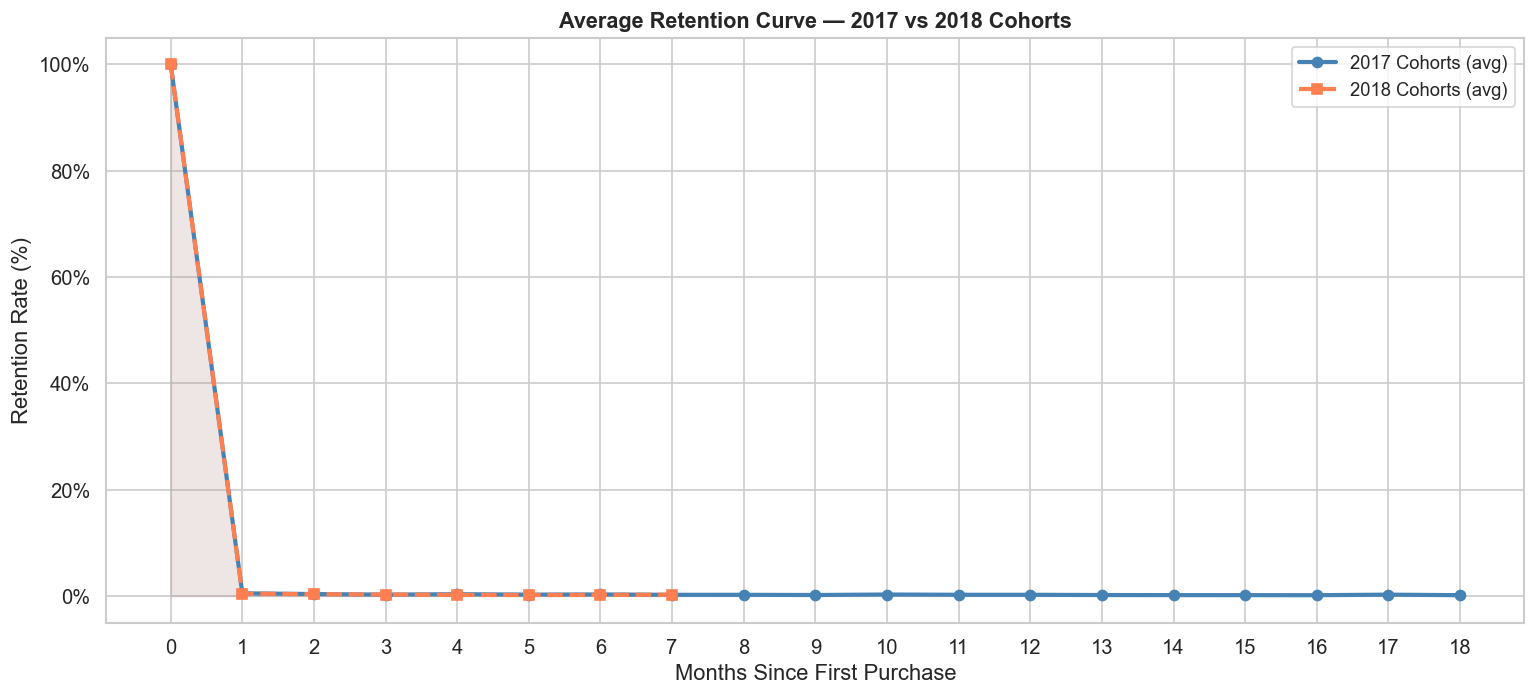

2017 Month-1 retention avg : 0.49%
2018 Month-1 retention avg : 0.45%


In [9]:
fig, ax = plt.subplots(figsize=(13, 6))

# Average retention curve per year
avg_2017_plot = cohorts_2017.mean() * 100
avg_2018_plot = cohorts_2018.mean() * 100

months = list(range(len(avg_2017_plot.dropna())))

ax.plot(avg_2017_plot.dropna().values,
        marker='o', linewidth=2.5, color='steelblue',
        label='2017 Cohorts (avg)')

ax.plot(avg_2018_plot.dropna().values,
        marker='s', linewidth=2.5, color='coral',
        label='2018 Cohorts (avg)', linestyle='--')

ax.fill_between(range(len(avg_2017_plot.dropna())),
                avg_2017_plot.dropna().values,
                alpha=0.1, color='steelblue')

ax.fill_between(range(len(avg_2018_plot.dropna())),
                avg_2018_plot.dropna().values,
                alpha=0.1, color='coral')

ax.set_title('Average Retention Curve — 2017 vs 2018 Cohorts',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Retention Rate (%)')
ax.legend(fontsize=11)
ax.set_xticks(range(len(avg_2017_plot.dropna())))
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

print(f"2017 Month-1 retention avg : {avg_2017_plot[1]:.2f}%")
print(f"2018 Month-1 retention avg : {avg_2018_plot[1]:.2f}%")

In [10]:
retention_report = pd.DataFrame({
    'cohort_index'       : avg_2017_plot.dropna().index.astype(int),
    'avg_retention_2017' : avg_2017_plot.dropna().values.round(2),
    'avg_retention_2018' : avg_2018_plot.reindex(avg_2017_plot.dropna().index,
                                                   fill_value=np.nan
                                                   ).values.round(2)
})

retention_report['yoy_change_pct'] = (
    retention_report['avg_retention_2018'] -
    retention_report['avg_retention_2017']
).round(2)

print("=== Year-over-Year Retention Comparison ===")
print(retention_report.to_string(index=False))

=== Year-over-Year Retention Comparison ===
 cohort_index  avg_retention_2017  avg_retention_2018  yoy_change_pct
            0              100.00              100.00            0.00
            1                0.49                0.45           -0.04
            2                0.35                0.32           -0.03
            3                0.25                0.26            0.01
            4                0.32                0.20           -0.12
            5                0.25                0.17           -0.08
            6                0.27                0.19           -0.08
            7                0.21                0.23            0.02
            8                0.21                 NaN             NaN
            9                0.17                 NaN             NaN
           10                0.26                 NaN             NaN
           11                0.21                 NaN             NaN
           12                0.21             

In [11]:
# How many customers were LOST each month from the starting cohort
dropoff_2017 = (cohorts_2017 * cohort_pivot[
    cohort_pivot.index.astype(str).str.startswith('2017')
][0].values.reshape(-1,1))

# Customers remaining at each month index
remaining_2017 = dropoff_2017.mean()

# Customers dropped = difference between consecutive months
dropped_2017 = remaining_2017.diff().abs()

print("=== 2017 Cohorts — Avg Customers Remaining per Month ===")
for idx, val in remaining_2017.dropna().items():
    lost = dropped_2017.get(idx, 0)
    print(f"  Month {int(idx):>2} : {val:>8.1f} customers remaining"
          f"  | dropped: {lost:>6.1f}")

=== 2017 Cohorts — Avg Customers Remaining per Month ===
  Month  0 :   3510.9 customers remaining  | dropped:    nan
  Month  1 :     18.3 customers remaining  | dropped: 3492.6
  Month  2 :     12.5 customers remaining  | dropped:    5.7
  Month  3 :      8.7 customers remaining  | dropped:    3.8
  Month  4 :     10.3 customers remaining  | dropped:    1.5
  Month  5 :      8.9 customers remaining  | dropped:    1.3
  Month  6 :      8.6 customers remaining  | dropped:    0.3
  Month  7 :      7.1 customers remaining  | dropped:    1.4
  Month  8 :      7.2 customers remaining  | dropped:    0.1
  Month  9 :      5.9 customers remaining  | dropped:    1.3
  Month 10 :      7.5 customers remaining  | dropped:    1.6
  Month 11 :      6.2 customers remaining  | dropped:    1.3
  Month 12 :      4.4 customers remaining  | dropped:    1.8
  Month 13 :      3.5 customers remaining  | dropped:    0.9
  Month 14 :      3.6 customers remaining  | dropped:    0.1
  Month 15 :      3.4 custom

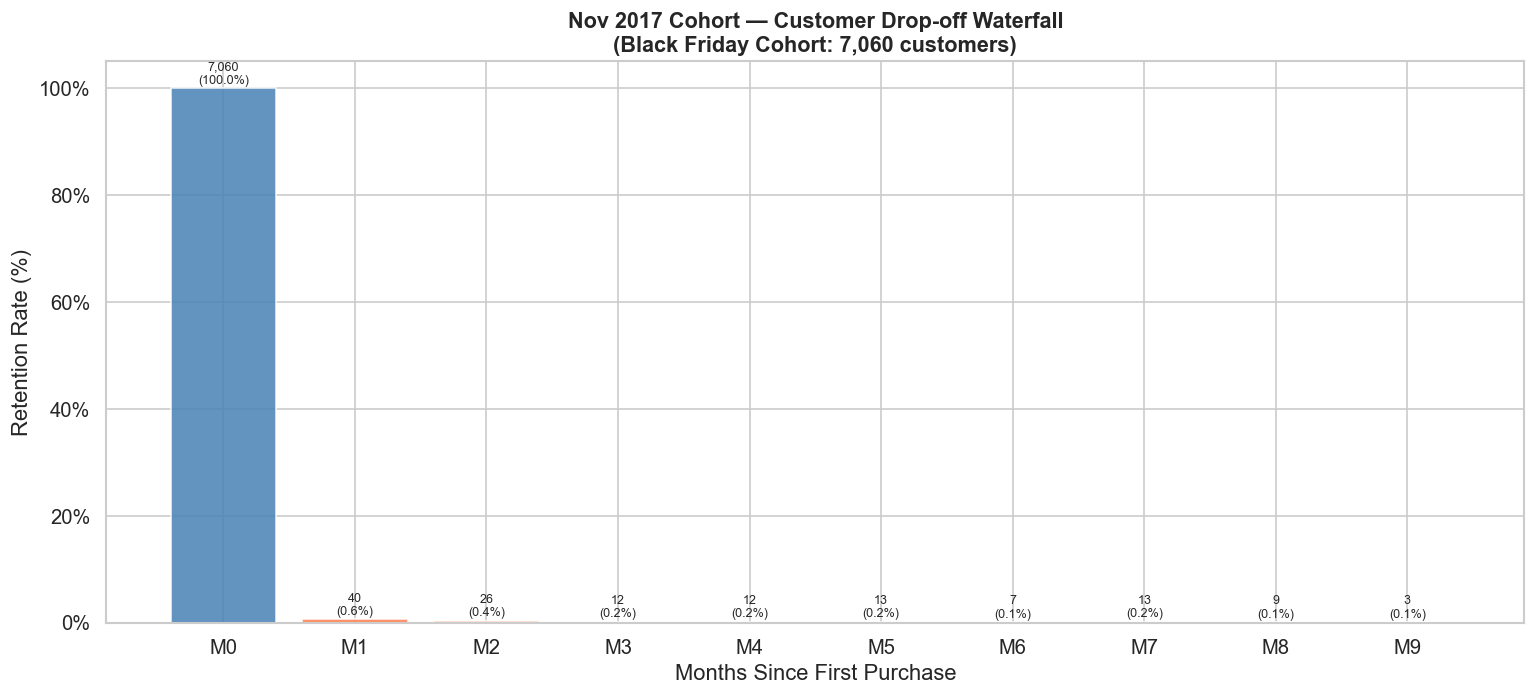

Nov 2017 cohort size    : 7,060 customers
Retained after month 1  : 40 customers (0.6%)
Retained after month 3  : 12 customers (0.2%)


In [12]:
# Use the largest 2017 cohort as example (Nov 2017 — Black Friday)
nov_cohort = cohort_pivot[cohort_pivot.index.astype(str) == '2017-11'].iloc[0]
nov_size   = nov_cohort[0]
nov_ret    = (nov_cohort / nov_size * 100).dropna()

fig, ax = plt.subplots(figsize=(13, 6))

colors = ['steelblue' if i == 0 else
          'coral'     if v < nov_ret.iloc[max(0, i-1)] else
          'mediumseagreen'
          for i, v in enumerate(nov_ret.values)]

bars = ax.bar(range(len(nov_ret)), nov_ret.values,
              color=colors, alpha=0.85, edgecolor='white')

# Label each bar with customer count
for i, (bar, val) in enumerate(zip(bars, nov_ret.values)):
    count = int(nov_size * val / 100)
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{count:,}\n({val:.1f}%)',
            ha='center', va='bottom', fontsize=7.5)

ax.set_title('Nov 2017 Cohort — Customer Drop-off Waterfall\n(Black Friday Cohort: 7,060 customers)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Retention Rate (%)')
ax.set_xticks(range(len(nov_ret)))
ax.set_xticklabels([f'M{i}' for i in range(len(nov_ret))])
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

print(f"Nov 2017 cohort size    : {int(nov_size):,} customers")
print(f"Retained after month 1  : {int(nov_size * nov_ret[1]/100)} customers ({nov_ret[1]:.1f}%)")
print(f"Retained after month 3  : {int(nov_size * nov_ret.get(3,0)/100)} customers ({nov_ret.get(3,0):.1f}%)")

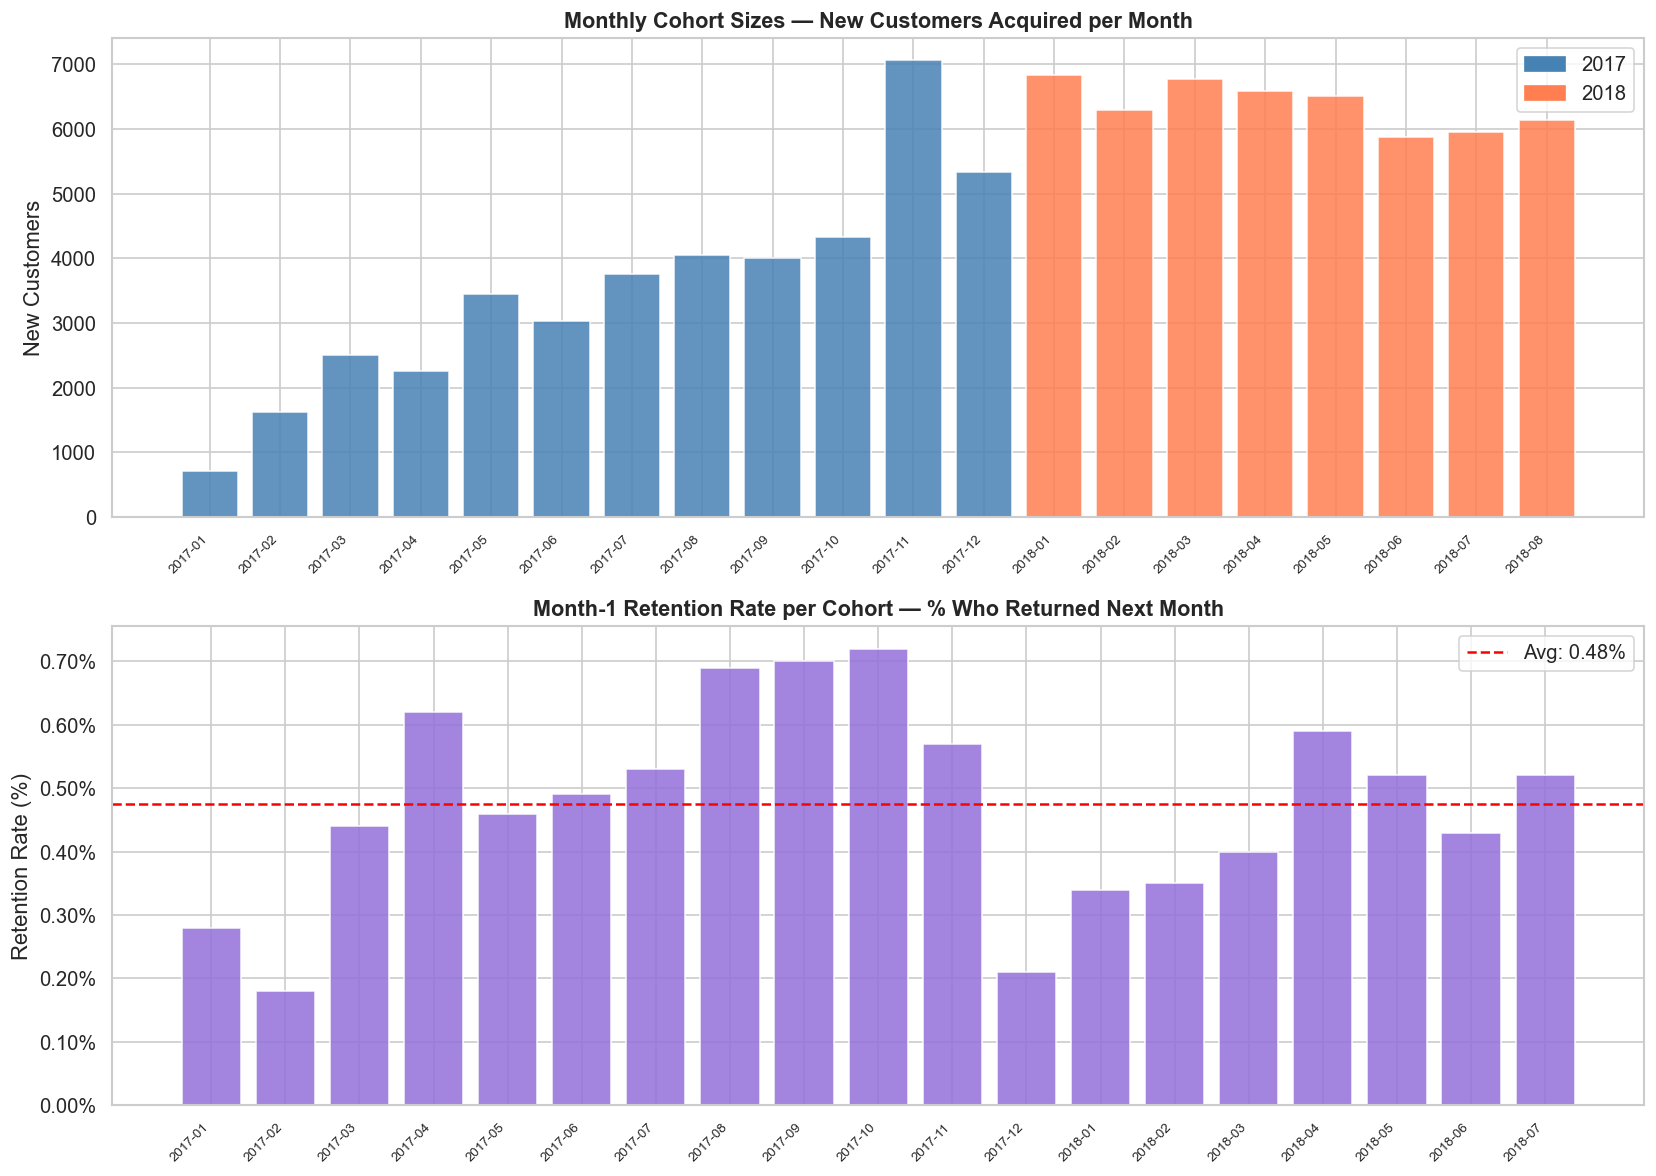

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top chart — cohort sizes over time
all_sizes = cohort_pivot[
    cohort_pivot.index.astype(str).str.startswith(('2017','2018'))
][0].reset_index()
all_sizes.columns = ['cohort_month', 'cohort_size']
all_sizes['year'] = all_sizes['cohort_month'].astype(str).str[:4]

colors_year = ['steelblue' if y == '2017' else 'coral'
               for y in all_sizes['year']]

axes[0].bar(range(len(all_sizes)),
            all_sizes['cohort_size'],
            color=colors_year, alpha=0.85)
axes[0].set_xticks(range(len(all_sizes)))
axes[0].set_xticklabels(
    all_sizes['cohort_month'].astype(str),
    rotation=45, ha='right', fontsize=8)
axes[0].set_title('Monthly Cohort Sizes — New Customers Acquired per Month')
axes[0].set_ylabel('New Customers')

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='steelblue', label='2017'),
    Patch(color='coral',     label='2018')
])

# Bottom chart — drop-off rate at month 1 per cohort
ret_month1 = retention_df[
    retention_df.index.astype(str).str.startswith(('2017','2018'))
][1].dropna() * 100

axes[1].bar(range(len(ret_month1)),
            ret_month1.values,
            color='mediumpurple', alpha=0.85)
axes[1].set_xticks(range(len(ret_month1)))
axes[1].set_xticklabels(
    ret_month1.index.astype(str),
    rotation=45, ha='right', fontsize=8)
axes[1].set_title('Month-1 Retention Rate per Cohort — % Who Returned Next Month')
axes[1].set_ylabel('Retention Rate (%)')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].axhline(ret_month1.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Avg: {ret_month1.mean():.2f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

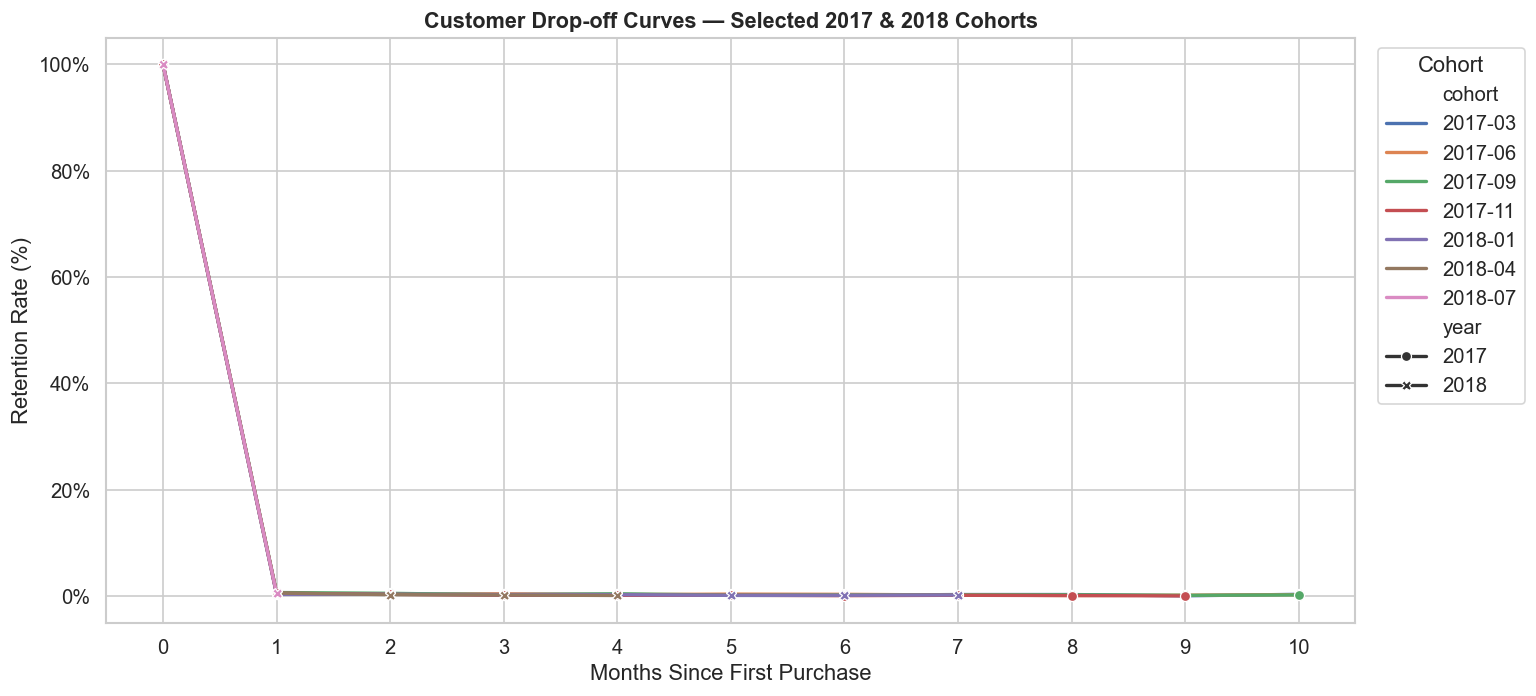

Steepest drop-off happens between Month 0 and Month 1 for all cohorts
This is the most critical window for retention intervention


In [14]:
# Build long-format data for seaborn
plot_cohorts = ['2017-03','2017-06','2017-09','2017-11',
                '2018-01','2018-04','2018-07']

long_data = []
for cohort in plot_cohorts:
    if cohort in retention_df.index.astype(str):
        row = retention_df[retention_df.index.astype(str) == cohort].iloc[0]
        for idx, val in row.dropna().items():
            long_data.append({
                'cohort'         : cohort,
                'month_index'    : int(idx),
                'retention_rate' : round(val * 100, 2),
                'year'           : cohort[:4]
            })

long_df = pd.DataFrame(long_data)
long_df = long_df[long_df['month_index'] <= 10]

fig, ax = plt.subplots(figsize=(13, 6))

sns.lineplot(
    data      = long_df,
    x         = 'month_index',
    y         = 'retention_rate',
    hue       = 'cohort',
    style     = 'year',
    markers   = True,
    dashes    = False,
    linewidth = 2,
    ax        = ax
)

ax.set_title('Customer Drop-off Curves — Selected 2017 & 2018 Cohorts',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Retention Rate (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xticks(range(11))
ax.legend(title='Cohort', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

print("Steepest drop-off happens between Month 0 and Month 1 for all cohorts")
print("This is the most critical window for retention intervention")

In [15]:
print("""
=== COHORT ANALYSIS — KEY FINDINGS ===

1. ACQUISITION GROWTH
   2017 avg monthly cohort : ~3,300 new customers
   2018 avg monthly cohort : ~6,370 new customers
   Growth                  : +93% more new customers per month

2. RETENTION REALITY
   Month-1 retention       : ~0.3% to 0.7% across all cohorts
   This means 99%+ of customers do NOT return the next month
   This is EXPECTED for a Brazilian general marketplace —
   customers buy when they need something, not habitually

3. BIGGEST DROP-OFF POINT
   Month 0 → Month 1 is the steepest fall for every cohort
   This is the most valuable window for email/push campaigns
   If a customer can be brought back within 30 days of first
   purchase, they are significantly more likely to become repeat buyers

4. NOVEMBER 2017 (BLACK FRIDAY COHORT)
   Largest cohort at 7,060 new customers
   But retention was consistent with other months —
   Black Friday buyers did not return more than regular buyers

5. RECOMMENDATION
   Focus retention budget on Month 0 → Month 1 re-engagement
   Target the HIGH_VALUE_SINGLE segment from the retention list
   (customers who spent 3x average in one order but never returned)
""")


=== COHORT ANALYSIS — KEY FINDINGS ===

1. ACQUISITION GROWTH
   2017 avg monthly cohort : ~3,300 new customers
   2018 avg monthly cohort : ~6,370 new customers
   Growth                  : +93% more new customers per month

2. RETENTION REALITY
   Month-1 retention       : ~0.3% to 0.7% across all cohorts
   This means 99%+ of customers do NOT return the next month
   This is EXPECTED for a Brazilian general marketplace —
   customers buy when they need something, not habitually

3. BIGGEST DROP-OFF POINT
   Month 0 → Month 1 is the steepest fall for every cohort
   This is the most valuable window for email/push campaigns
   If a customer can be brought back within 30 days of first
   purchase, they are significantly more likely to become repeat buyers

4. NOVEMBER 2017 (BLACK FRIDAY COHORT)
   Largest cohort at 7,060 new customers
   But retention was consistent with other months —
   Black Friday buyers did not return more than regular buyers

5. RECOMMENDATION
   Focus retention

In [16]:
# Export 1 — full retention matrix
retention_pct_export = (retention_df * 100).round(2)
retention_pct_export.to_csv('cohort_retention_matrix.csv')
print("cohort_retention_matrix.csv exported ✓")

# Export 2 — retention report (2017 vs 2018 comparison)
retention_report.to_csv('cohort_retention_report.csv', index=False)
print("cohort_retention_report.csv exported ✓")

# Export 3 — long format for dashboards
long_df.to_csv('cohort_dropoff_curves.csv', index=False)
print("cohort_dropoff_curves.csv exported ✓")

print(f"\nAll cohort exports complete")

cohort_retention_matrix.csv exported ✓
cohort_retention_report.csv exported ✓
cohort_dropoff_curves.csv exported ✓

All cohort exports complete
